<a href="https://colab.research.google.com/github/Ardatatl33/turk-yeyapayzekaakademisi_bootcamp/blob/main/VeriBilimiFinalOdev.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [85]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [86]:
df = pd.read_csv("/content/e_ticaret_veri_seti_aykiri_degerler_duzenlendi.csv")
pd.set_option("display.max_columns", None)
df.head()

,siparis_id,musteri_id,siparis_tarihi,sehir,bolge,kategori,urun_adi,adet,birim_fiyat,indirim_orani,kargo_ucreti,odeme_turu,musteri_tipi,teslimat_gunu,musteri_puani,iade_durumu,kar_marji_orani,toplam_tutar,siparis_yili,siparis_ayi,siparis_gunu,haftanin_gunu
0,SIP101125,MUS1391,2024-01-13 17:06:00,İstanbul,Marmara,Kozmetik,Nemlendirici,1,414.51,0.05,49.9,Kredi Kartı,Yeni,3.0,5.0,Hayır,0.220,443.68,2024,1,13,Saturday
1,SIP100263,MUS1008,2024-08-10 15:13:00,Antalya,Akdeniz,Kitap,Girişimcilik,5,194.78,0.00,49.9,Kapıda Ödeme,Yeni,3.0,5.0,Hayır,0.250,1023.80,2024,8,10,Saturday
2,SIP100707,MUS1291,2024-08-19 08:24:00,Gaziantep,Güneydoğu Anadolu,Elektronik,Powerbank,3,841.80,0.05,39.9,Dijital Cüzdan,Mevcut,4.0,5.0,Hayır,0.280,2439.03,2024,8,19,Monday
3,SIP100687,MUS1147,2025-08-09 08:42:00,Konya,İç Anadolu,Kozmetik,Nemlendirici,2,417.02,0.00,59.9,Dijital Cüzdan,Mevcut,4.0,5.0,Hayır,0.220,893.94,2025,8,9,Saturday
4,SIP100254,MUS1447,2024-07-30 09:06:00,Konya,İç Anadolu,Elektronik,Bluetooth Hoparlör,1,1327.75,0.05,29.9,Banka Kartı,Mevcut,4.0,5.0,Hayır,0.283,1291.26,2024,7,30,Tuesday


In [87]:
kategori_siparis_sayisi_analiz = (
    df.groupby("kategori")
    .agg(
        toplam_gelir=("toplam_tutar","sum"),
        toplam_siparis=("kategori","count"),
        ortalama_fiyat=("toplam_tutar","mean"),
        ortalama_musteri_puani=("musteri_puani","mean"),
        ortalama_teslimat_gunu=("teslimat_gunu","mean"),
    ).round(2)
    .reset_index()
)
kategori_siparis_sayisi_analiz
# kategorilere göre toplam gelir,sipariş sayısı,ortalama fiyat ,ortalama müşteri puanı ve ortalama teslimat günü analizi yapıp tablolaştırdık

,kategori,toplam_gelir,toplam_siparis,ortalama_fiyat,ortalama_musteri_puani,ortalama_teslimat_gunu
0,Elektronik,212930.29,140,1520.93,4.24,3.32
1,Ev Yaşam,142335.55,184,773.56,4.26,3.45
2,Kitap,114075.59,223,511.55,4.25,3.42
3,Kozmetik,147522.90,200,737.61,4.42,3.35
4,Ofis,47051.88,162,290.44,4.24,3.13
5,Spor,189481.91,186,1018.72,4.26,3.18


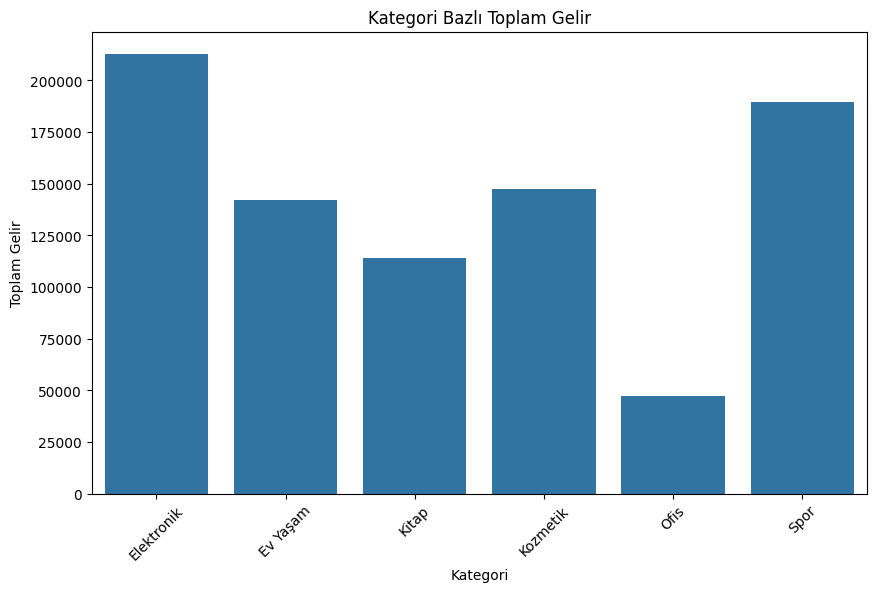

In [88]:
plt.figure(figsize = (10,6))
sns.barplot(data = kategori_siparis_sayisi_analiz ,x = "kategori", y="toplam_gelir")
plt.title("Kategori Bazlı Toplam Gelir")
plt.xlabel("Kategori")
plt.ylabel("Toplam Gelir")
plt.xticks(rotation = 45)
plt.show()
# Bu grafiğe göre en fazla gelir getiren kategorinin elektronik olduğunu görüyrouz ve bizi arkasından spor takip ediyor

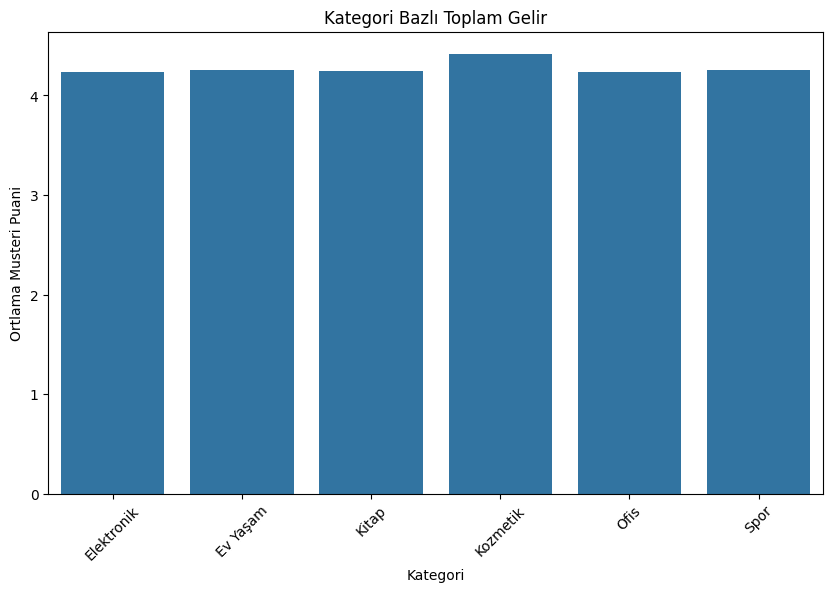

In [89]:
plt.figure(figsize = (10,6))
sns.barplot(data = kategori_siparis_sayisi_analiz ,x = "kategori", y="ortalama_musteri_puani")
plt.title("Kategori Bazlı Toplam Gelir")
plt.xlabel("Kategori")
plt.ylabel("Ortlama Musteri Puani")
plt.xticks(rotation = 45)
plt.show()
# Kozmetikte ortalama puanımızın en yüksek olduğunu görüyrouz

In [90]:
# 5. maddede ne istenildiğini tam anlamadım ama en yüksek gelir ve en yüksek ortalamayı bulmam isteniyor gibi anladım
en_yuksek_gelir = kategori_siparis_sayisi_analiz["toplam_gelir"].idxmax()
en_yuksek_ortalama = kategori_siparis_sayisi_analiz["ortalama_musteri_puani"].idxmax()


In [91]:
print(f"En yüksek toplam gelire sahip kategori : {kategori_siparis_sayisi_analiz["kategori"].iloc[en_yuksek_gelir]}")
print(f"En yüksek müşteri puan ortlamasına sahip kategori :{kategori_siparis_sayisi_analiz["kategori"].iloc[en_yuksek_ortalama]}")
# En yüksek gelir getiren kategori elektronik olurken en yüksek müşteri puan ortalamasına sahip kategori kozmetiktir.bu konu elektroniğin birim fiyatının yüksek olmasıyla ilgili olabilir ama müşterilerin kozmetik kategorisinde puanı iyi seyir ediyor

En yüksek toplam gelire sahip kategori : Elektronik
En yüksek müşteri puan ortlamasına sahip kategori :Kozmetik


In [92]:
sehir_bazli_analiz = (
    df.groupby("sehir")
    .agg(
        toplam_gelir=("toplam_tutar","sum"),
        toplam_siparis=("kategori","count"),
        ortalama_fiyat=("toplam_tutar","mean"),
        ortalama_musteri_puani=("musteri_puani","mean")
    ).round(2)
    .reset_index()
)
sehir_bazli_analiz
# Sehir bazlı analiz yaparak sehirlerden verilen siparişlerin toplam gelir getirisini,toplam verdikleri siparişi,ortalama fiyatarı ve ortalama müşteri puanlarını tablolaştırıyoruz

,sehir,toplam_gelir,toplam_siparis,ortalama_fiyat,ortalama_musteri_puani
0,Adana,50353.28,63,799.26,4.33
1,Ankara,96721.13,124,780.01,4.19
2,Antalya,63712.80,86,740.85,4.28
3,Bursa,46782.83,67,698.25,4.21
4,Eskişehir,37550.04,45,834.45,4.24
5,Gaziantep,35240.29,49,719.19,4.35
6,Kayseri,24878.81,36,691.08,4.28
7,Kocaeli,21293.02,31,686.87,4.19
8,Konya,59424.33,77,771.74,4.36
9,Mersin,38043.87,46,827.04,4.22


In [93]:
sehir_bazli_analiz = sehir_bazli_analiz.sort_values("toplam_gelir",ascending=False)
sehir_bazli_analiz
# Toplam gelirin azalan sırasına göre sehirlerimizi görüyoruz istanbul bu konuda lider durumda nüfusundan kaynaklanması çok ihtimalli

,sehir,toplam_gelir,toplam_siparis,ortalama_fiyat,ortalama_musteri_puani
12,İstanbul,224020.57,264,848.56,4.36
1,Ankara,96721.13,124,780.01,4.19
13,İzmir,88718.51,118,751.85,4.18
2,Antalya,63712.80,86,740.85,4.28
8,Konya,59424.33,77,771.74,4.36
0,Adana,50353.28,63,799.26,4.33
3,Bursa,46782.83,67,698.25,4.21
9,Mersin,38043.87,46,827.04,4.22
4,Eskişehir,37550.04,45,834.45,4.24
10,Samsun,36263.46,45,805.85,4.44


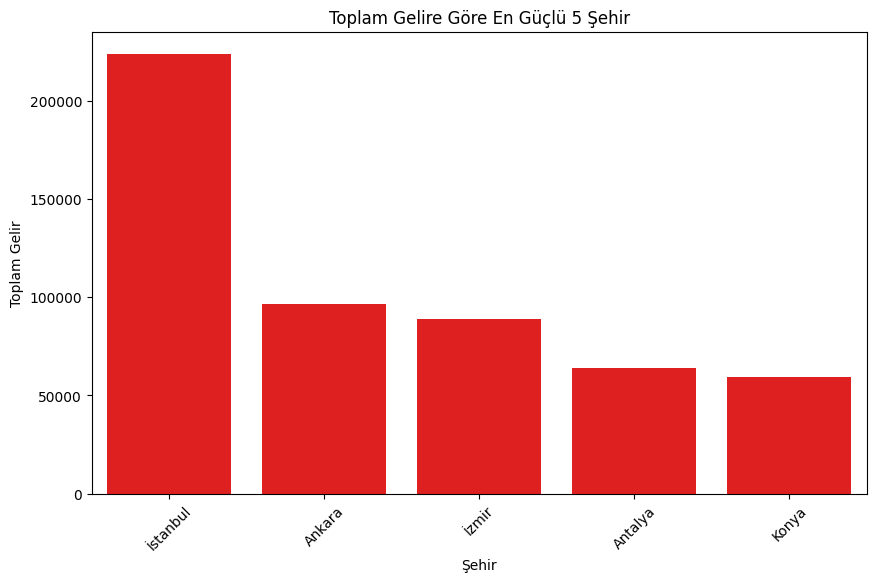

In [94]:
en_guclu_5_sehir = sehir_bazli_analiz.head().reset_index()
plt.figure(figsize = (10,6))
sns.barplot(data = en_guclu_5_sehir ,x = "sehir", y="toplam_gelir",color = "red")
plt.title("Toplam Gelire Göre En Güçlü 5 Şehir")
plt.xlabel("Şehir")
plt.ylabel("Toplam Gelir")
plt.xticks(rotation=45)
plt.show()
# Getirdiği gelir getirisi olarak en güçlü 5 şehiri grafikleştirdik İstanbul bu konuda zirvedeyken onu Ankara, İzmir , Antalya , Konya gibi şehirler takip ediyor bu durumda nüfusla orantılı olduğunu görüyoruz.

In [95]:
buyume_adayı_sehirler = (
    df.groupby("sehir")
    .agg(
        toplam_gelir=("toplam_tutar","sum"),
        ortalama_musteri_puani=("musteri_puani","mean")
    ).round(2)
    .reset_index()
    .sort_values("ortalama_musteri_puani",ascending=False)
)
buyume_adayı_sehirler
# Buyume adayı şehirlere bakıyoruz özellikle samsun , kasyseri ve eskişehir müşteri memnuniyeti olarak gayet iyi geri dönütler vermiş bu şehirlerdeki geliride arttırmak için çalışma yapmamız gerekiyor

,sehir,toplam_gelir,ortalama_musteri_puani
10,Samsun,36263.46,4.44
8,Konya,59424.33,4.36
12,İstanbul,224020.57,4.36
5,Gaziantep,35240.29,4.35
0,Adana,50353.28,4.33
2,Antalya,63712.80,4.28
6,Kayseri,24878.81,4.28
4,Eskişehir,37550.04,4.24
11,Trabzon,30395.18,4.23
9,Mersin,38043.87,4.22


In [96]:
odeme_turu_degerli_musteri_analizi = (
    df.groupby("odeme_turu")
    .agg(
        toplam_gelir =("toplam_tutar","sum"),
        toplam_siparis =("kategori","count"),
        ortalama_siparis_tutari =("toplam_tutar","mean"),
        ortalama_musteri_puani =("musteri_puani","mean"),
        ortalama_teslimat_gunu =("teslimat_gunu","mean"),
    ).round(2)
    .reset_index()
)
odeme_turu_degerli_musteri_analizi
# odeme turune göre hangi müşterilerin nereden daha fazla gelir getirdiğine hangi ödeme türüne daha çok odaklanıldığına dair bir tablo oluşturduk

,odeme_turu,toplam_gelir,toplam_siparis,ortalama_siparis_tutari,ortalama_musteri_puani,ortalama_teslimat_gunu
0,Banka Kartı,143011.08,169,846.22,4.24,3.53
1,Dijital Cüzdan,129911.25,153,849.09,4.27,3.27
2,Havale/EFT,92894.46,111,836.89,4.15,3.14
3,Kapıda Ödeme,48113.17,79,609.03,4.38,3.24
4,Kredi Kartı,439468.16,583,753.80,4.31,3.31


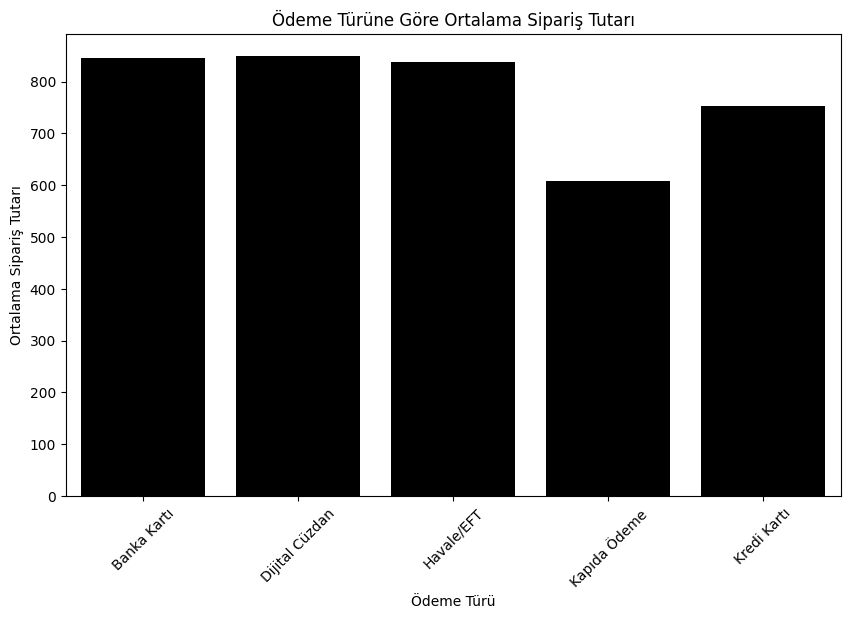

In [97]:
plt.figure(figsize = (10,6))
sns.barplot(data = odeme_turu_degerli_musteri_analizi ,x = "odeme_turu", y="ortalama_siparis_tutari",color="black")
plt.title("Ödeme Türüne Göre Ortalama Sipariş Tutarı")
plt.xlabel("Ödeme Türü")
plt.ylabel("Ortalama Sipariş Tutarı")
plt.xticks(rotation = 45)
plt.show()
# En çok ödeme yönteminin kartlarla olduğunu görüyoruz müşteriler kartla alışverişi daha güvenli buluyor olabilir

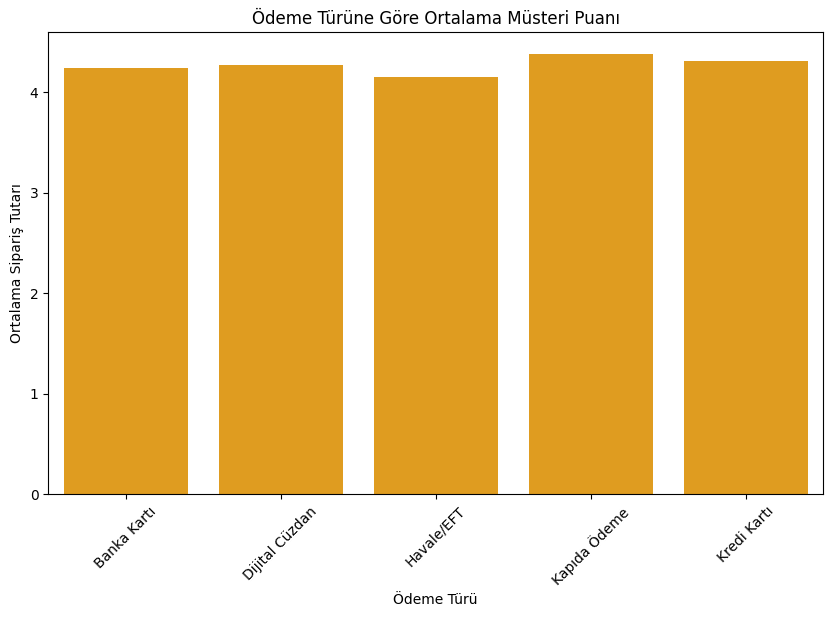

In [98]:
plt.figure(figsize = (10,6))
sns.barplot(data = odeme_turu_degerli_musteri_analizi ,x = "odeme_turu", y="ortalama_musteri_puani",color="orange")
plt.title("Ödeme Türüne Göre Ortalama Müsteri Puanı")
plt.xlabel("Ödeme Türü")
plt.ylabel("Ortalama Sipariş Tutarı")
plt.xticks(rotation = 45)
plt.show()
# En yüksek puanı kapıda ödemeden almışız insanların ürünü gördükten sonra ücret ödemesi yapması puanlarda gayet etkili olduğunu belirtiyor. Kapıda ödemeye çalışma yapıp  gelirinide arttırmalıyız

In [99]:
en_yuksek_gelir = odeme_turu_degerli_musteri_analizi["toplam_gelir"].idxmax()
en_yuksek_ortalama = odeme_turu_degerli_musteri_analizi["ortalama_musteri_puani"].idxmax()

In [100]:
print(f"En Yüksek Gelir Üreten Ödeme Yöntemi : {odeme_turu_degerli_musteri_analizi["odeme_turu"].iloc[en_yuksek_gelir]}")
print(f"En Yüksek Müsteri Puanına Sahip Ödeme Yöntemi : {odeme_turu_degerli_musteri_analizi["odeme_turu"].iloc[en_yuksek_ortalama]}")
#En yüksek geliri kredi kartından alırken en yüksek müşteri puanını kapıda ödemeden almışız yeni bir e ticaret sitesi olduğmuzu varsayarsak insanların güvenini kazanmışız kredi kartı gelirimiz gayet yüksek kapıda ödeme gelirininde zamanla diğer ödeme yöntemlerine kayıcağını düşünüyorum ve buda müşteri puanlarımızın diğer ödeme türlerinde artıcağını gösterir

En Yüksek Gelir Üreten Ödeme Yöntemi : Kredi Kartı
En Yüksek Müsteri Puanına Sahip Ödeme Yöntemi : Kapıda Ödeme


In [101]:
df["siparis_tarihi"] = pd.to_datetime(df["siparis_tarihi"])
df["siparis_yili"] = df["siparis_tarihi"].dt.year
df["siparis_ayi"] = df["siparis_tarihi"].dt.month
df["siparis_gunu"] = df["siparis_tarihi"].dt.day
df["haftanin_gunu"] = df["siparis_tarihi"].dt.day_name()

In [102]:
aylık_analiz = (
    df.groupby("siparis_ayi")
    .agg(
        toplam_gelir=("toplam_tutar","sum"),
        toplam_siparis =("kategori","count"),
        ortalama_siparis_tutari = ("toplam_tutar","mean"),
    ).round(2)
    .reset_index()
)
aylık_analiz
#müşterilerin hangi ayda daha çok alışveriş yatığını anlicağımız hangi ayda daha çok gelir aldğımız bir tablo oluşturuyoruz

,siparis_ayi,toplam_gelir,toplam_siparis,ortalama_siparis_tutari
0,1,68309.45,97,704.22
1,2,67984.01,84,809.33
2,3,70857.89,94,753.81
3,4,68630.39,111,618.29
4,5,92213.41,102,904.05
5,6,77526.88,85,912.08
6,7,68774.62,79,870.56
7,8,55945.11,80,699.31
8,9,80591.62,91,885.62
9,10,60860.45,89,683.83


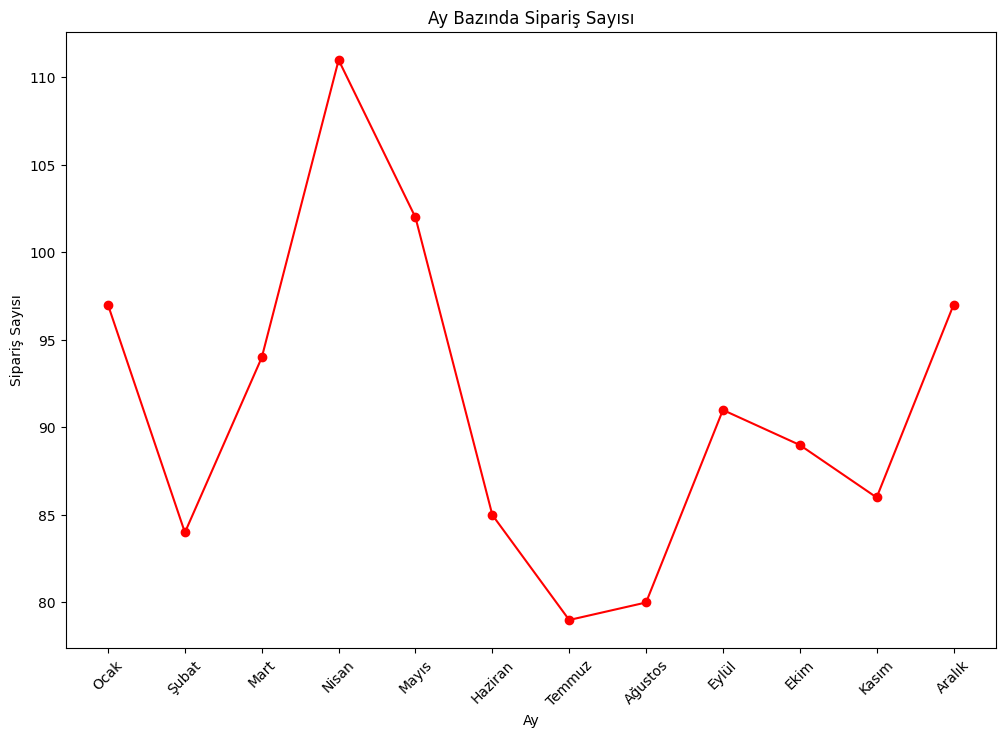

In [104]:
aylar = ["Ocak","Şubat","Mart","Nisan","Mayıs","Haziran",
         "Temmuz","Ağustos","Eylül","Ekim","Kasım","Aralık"]

plt.figure(figsize=(12,8))
plt.plot(aylık_analiz["siparis_ayi"],aylık_analiz["toplam_siparis"],marker = "o",color = "red")
plt.title("Ay Bazında Sipariş Sayısı")
plt.xlabel("Ay")
plt.ylabel("Sipariş Sayısı")
plt.xticks(range(1,13), aylar, rotation=45)
plt.show()
# Burada grafikte görüldüğü üzere Nisan ayında çok fazla sipariş almışız

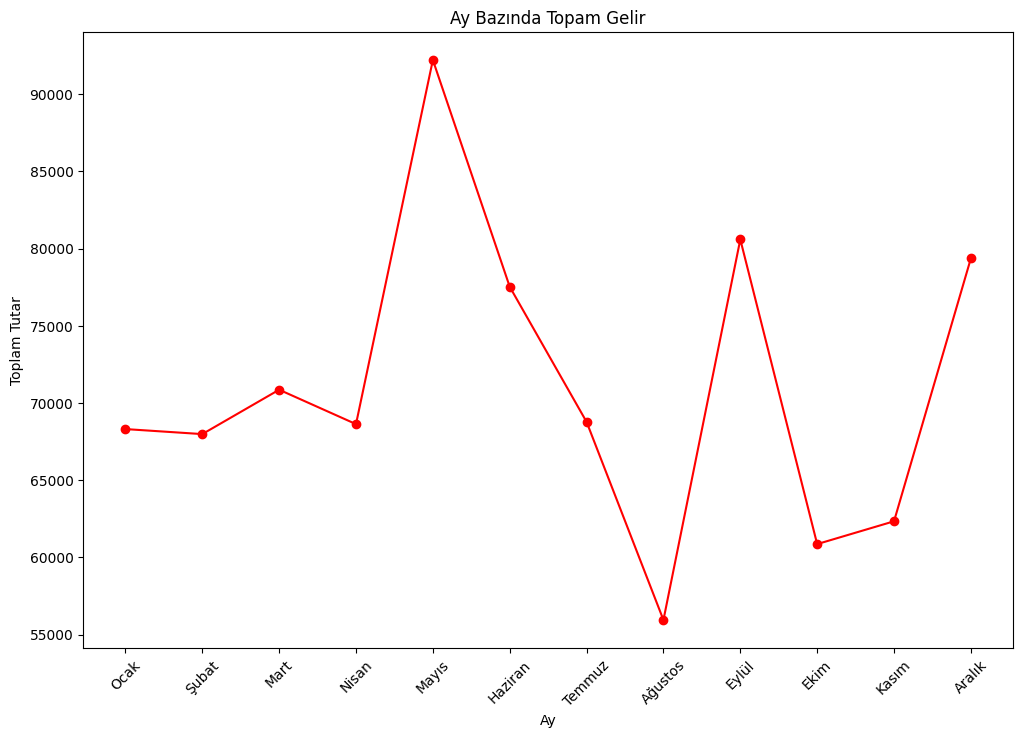

In [107]:
aylar = ["Ocak","Şubat","Mart","Nisan","Mayıs","Haziran",
         "Temmuz","Ağustos","Eylül","Ekim","Kasım","Aralık"]

plt.figure(figsize=(12,8))
plt.plot(aylık_analiz["siparis_ayi"],aylık_analiz["toplam_gelir"],marker = "o",color = "red")
plt.title("Ay Bazında Topam Gelir")
plt.xlabel("Ay")
plt.ylabel("Toplam Tutar")
plt.xticks(range(1,13), aylar, rotation=45)
plt.show()
# Ama burada en fazla gelir getiren ayın mayıs olduğunu görüyoruz bunun sebebi nisan ayında birim fiyatı düşük ürünlere yöneldiğini anlayabiliriz ayrıca ağustos ayında gelirin neden grafiğin altta kaldığını anlamak için çalışma yapmamız gerekiyor

In [111]:
en_yuksek_gelir = aylık_analiz["toplam_gelir"].idxmax()
en_yogun_ay = aylık_analiz["toplam_siparis"].idxmax()

In [116]:
aylar = [
    "", "Ocak", "Şubat", "Mart", "Nisan", "Mayıs", "Haziran",
    "Temmuz", "Ağustos", "Eylül", "Ekim", "Kasım", "Aralık"
]

print("En yüksek gelirin olduğu ay:", aylar[aylık_analiz["siparis_ayi"].iloc[en_yuksek_gelir]])
print("En yoğun ay:", aylar[aylık_analiz["siparis_ayi"].iloc[en_yogun_ay]])
# Sipariş artışı ve gelir artışı aynı anda gelişmiyor bunun sebebi müşterilerin nisan ayında birim fiyatı daha düşük ürünlere yönelip mayıs ayında birim fiyatı daha yüksek ürünlere yönelmesi olabilir

En yüksek gelirin olduğu ay: Mayıs
En yoğun ay: Nisan


In [120]:
sehir_ve_kategori_bazli_analiz = (
    df.groupby(["sehir","kategori"])
    .agg(
        toplam_gelir=("toplam_tutar","sum"),
        toplam_siparis=("kategori","count"),
        ortalama_fiyat=("toplam_tutar","mean"),
        ortalama_musteri_puani=("musteri_puani","mean")
    ).round(2)
    .reset_index()
    .sort_values("toplam_gelir",ascending=False)
)
pd.set_option("display.max_rows", None)
sehir_ve_kategori_bazli_analiz
# En güçlü şehir, kategori kombinasyonunu bulmak için bir tablomuz var

,sehir,kategori,toplam_gelir,toplam_siparis,ortalama_fiyat,ortalama_musteri_puani
72,İstanbul,Elektronik,66731.92,45,1482.93,4.18
77,İstanbul,Spor,53391.34,43,1241.66,4.33
73,İstanbul,Ev Yaşam,34130.59,43,793.73,4.42
75,İstanbul,Kozmetik,33167.28,42,789.70,4.55
74,İstanbul,Kitap,27106.12,56,484.04,4.29
83,İzmir,Spor,25196.08,26,969.08,4.15
6,Ankara,Elektronik,23401.32,15,1560.09,4.13
11,Ankara,Spor,22817.79,23,992.08,4.35
48,Konya,Elektronik,22342.84,15,1489.52,4.40
78,İzmir,Elektronik,18487.02,14,1320.50,4.21


In [123]:
en_guclu_10 = sehir_ve_kategori_bazli_analiz.head(10).reset_index()
en_guclu_10
#en güçlü 10 şehir, kategori kombinasyonunu table şeklinde görüyoruz

,index,sehir,kategori,toplam_gelir,toplam_siparis,ortalama_fiyat,ortalama_musteri_puani
0,72,İstanbul,Elektronik,66731.92,45,1482.93,4.18
1,77,İstanbul,Spor,53391.34,43,1241.66,4.33
2,73,İstanbul,Ev Yaşam,34130.59,43,793.73,4.42
3,75,İstanbul,Kozmetik,33167.28,42,789.70,4.55
4,74,İstanbul,Kitap,27106.12,56,484.04,4.29
5,83,İzmir,Spor,25196.08,26,969.08,4.15
6,6,Ankara,Elektronik,23401.32,15,1560.09,4.13
7,11,Ankara,Spor,22817.79,23,992.08,4.35
8,48,Konya,Elektronik,22342.84,15,1489.52,4.40
9,78,İzmir,Elektronik,18487.02,14,1320.50,4.21


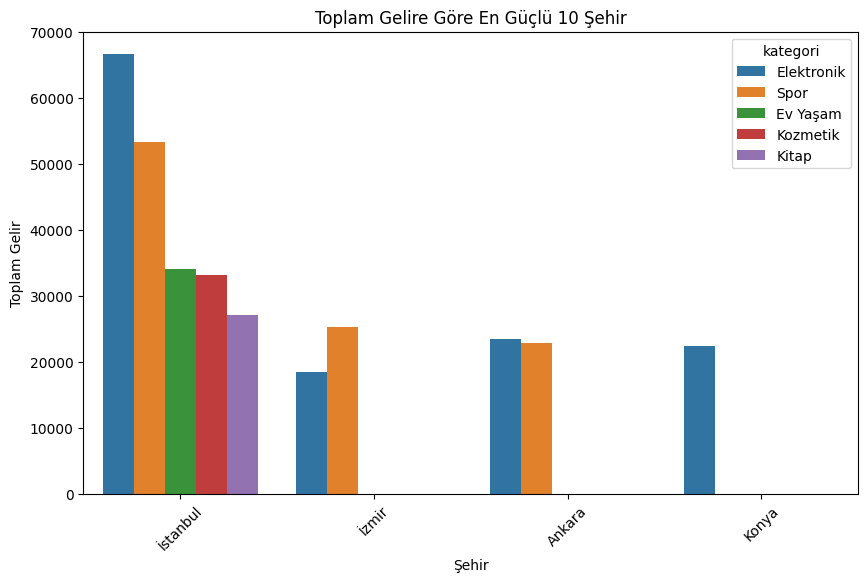

In [124]:
plt.figure(figsize = (10,6))
sns.barplot(data = en_guclu_10 ,x = "sehir", y="toplam_gelir",hue="kategori")
plt.title("Toplam Gelire Göre En Güçlü 10 Şehir")
plt.xlabel("Şehir")
plt.ylabel("Toplam Gelir")
plt.xticks(rotation=45)
plt.show()
# Grafiğe baktığımızda İstanbulda Elektronik iyi bir farkla önde

In [127]:
idx = sehir_ve_kategori_bazli_analiz["toplam_gelir"].idxmax()
en_guclu = sehir_ve_kategori_bazli_analiz.loc[idx]

print(
    f"En güçlü kombinasyon ikilisi: "
    f"{en_guclu['sehir']} - {en_guclu['kategori']} "
    f"(Toplam gelir: {en_guclu['toplam_gelir']:,.2f})"
)
# Kampanya yapmanın gelir oranımızı yükselticektir istanbulda elektroniğe büyük bir yatırım var , pazarlamamızda reklamlarımızı artırıp doğru sonuçlar alıcağımızı düşünüyorum iyi kampanyalar yapıp bunu duyurarak , ürün strateji olarak ise yurtdışı pazarına yönelerek yurtdışında hype ürünleri ithalat yapabiliriz yenilikçi ve doğr bir düşünce olduğunu düşünüyorum.

En güçlü kombinasyon ikilisi: İstanbul - Elektronik (Toplam gelir: 66,731.92)
